# Figure 14.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Similar to Figure 1 except for the absolute difference in Lagrangian dust densities $\Delta\rho_\mathrm{d}$ between Athena++ and PLUTO models (i.e., the former minus the latter; cf. positive red values here with the upper Athena++ row in Figure 1), initialized with the same particle positions and velocities (at $t = 0$; Section 4.1), and with snapshots as early as $t = 1T$.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

res = 512
root = f'../{res}/src'
n_p = 'np1'
runs = {
    f'dust_particles/{n_p}': {
        'ls': 'dotted',
        'codes' : {
            'Athena++':     'tab:red',
            'PLUTO-PI':     'tab:pink'
        }
    }
}

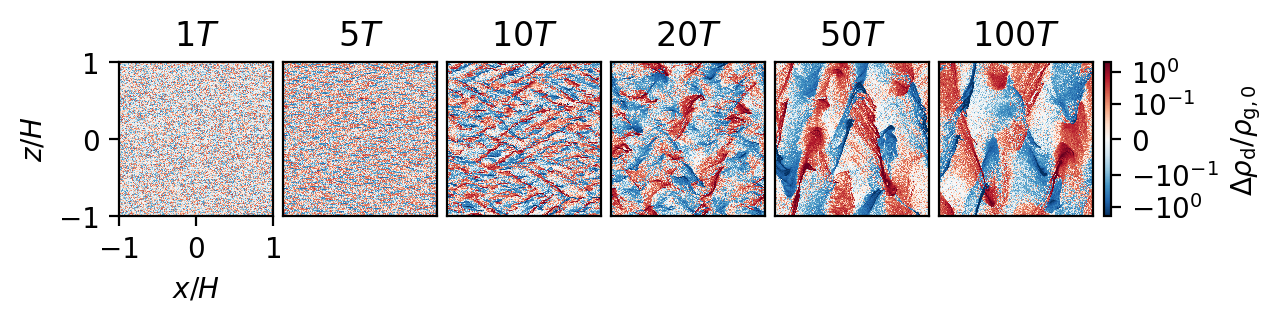

In [2]:
#===============================================================================
times = [1, 5, 10, 20, 50, 100]
vmin, vmax = 2e-2, 2e0 # BA CDF(rhop) > 90%; CDF(rhop) < 1%
nrows = 1
ref = []

# Plot
fig = plt.figure(figsize=(8, 1), dpi=200)
ax_grid = AxesGrid(fig, 111, nrows_ncols=(nrows, len(times)), axes_pad=0.05,
                   share_all=True, label_mode='1')
j = 0
for key, value in runs.items():
    for code in value['codes']:
        path = f'{root}/{key}/{code}'
        row = j*len(times)
        for i, time in enumerate(times):
            if j == 0:
                ax_grid[i].set_title(rf'{time}$T$')
            snapshot = np.load(f'{path}/{time}.npz')
            x = snapshot['x']
            z = snapshot['z']
            try:
                rhod = snapshot['rhod']
            except KeyError:
                print(f'KeyError: {code}')
            clip = np.clip(rhod, vmin, vmax)
            if code == 'Athena++':
                ref.append(rhod)
                continue
            diff = ref[i] - rhod
            pcm = ax_grid[row+i].pcolormesh(x, z, diff, rasterized=True,
                                            cmap='RdBu_r', norm=colors.SymLogNorm(
                                            vmin=-2, vmax=2, linthresh=0.1))
            ax_grid[row+i].tick_params(bottom=False, left=False)

# Format plots
plt.colorbar(pcm, anchor=(0.355, 0),
             label=r'$\Delta\rho_\mathrm{d}/\rho_\mathrm{g,0}$')
bot_left = len(ax_grid)-len(times)
ax_grid[bot_left].set(xlabel=r'$x/H$', ylabel=r'$z/H$')
ax_grid[bot_left].tick_params(bottom=True, left=True)